# Análisis descriptivo del dataset BIRD-SQL para Text-to-SQL

Este notebook realiza una exploración del conjunto **BIRD-SQL**, específicamente de la versión de entrenamiento filtrada `bird23-train-filtered`.

El análisis cubre:

1. Fuente y licencia.
2. Estructura y dimensiones.
3. Variables y significado.
4. Frecuencias de categorías relevantes.
5. Histogramas y diagramas de dispersión.
6. Nube de palabras.
7. Características de las consultas SQL.
8. Uso del campo `evidence`.
9. Justificación del dataset para un proyecto de Text-to-SQL.

La versión filtrada se utiliza porque el equipo de BIRD realizó un control de calidad para conservar ejemplos consistentes con el esquema y con la respuesta esperada.

## 1. Fuente y licencia

**BIRD-SQL** (*BIg Bench for LaRge-scale Database Grounded Text-to-SQL Evaluation*) es un benchmark diseñado para evaluar Text-to-SQL en bases de datos de mayor escala y con conocimiento externo asociado a las preguntas.

Para este análisis se utiliza:

- **Dataset:** `birdsql/bird23-train-filtered`
- **Hugging Face:** https://huggingface.co/datasets/birdsql/bird23-train-filtered
- **Proyecto BIRD:** https://bird-bench.github.io/
- **Licencia indicada en Hugging Face:** CC BY-SA 4.0.
- **Idioma:** inglés.

La versión filtrada contiene **6.601 ejemplos**, seleccionados a partir del conjunto de entrenamiento original luego de un proceso de control de calidad.

A diferencia de Spider, BIRD incluye explícitamente un campo `evidence`, que representa conocimiento adicional que puede ser necesario para interpretar correctamente la pregunta y construir la consulta SQL.

In [4]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from wordcloud import WordCloud


In [ ]:
from pathlib import Path

# Guarda cada figura como PNG dentro de Proyecto/Datos/graficas_<dataset>.
# Tambi?n funciona si el directorio actual ya es Proyecto/Datos.
RUTA_DATOS = Path("Proyecto/Datos")
if not RUTA_DATOS.is_dir():
    RUTA_DATOS = Path(".")
CARPETA_GRAFICAS = RUTA_DATOS / "graficas_bird"
CARPETA_GRAFICAS.mkdir(parents=True, exist_ok=True)

def guardar_grafica(nombre_archivo):
    ruta = CARPETA_GRAFICAS / f"{nombre_archivo}.png"
    plt.savefig(ruta, dpi=300, bbox_inches="tight")
    print(f"Gr?fica guardada en: {ruta.resolve()}")


## 2. Carga del dataset

In [5]:
bird = load_dataset("birdsql/bird23-train-filtered")

print(bird)

c:\Users\adwar\miniconda3\envs\ir\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\adwar\.cache\huggingface\hub\datasets--birdsql--bird23-train-filtered. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 6601/6601 [00:00<00:00, 210178.48 examples/s]

DatasetDict({
    train: Dataset({
        features: ['db_id', 'question', 'evidence', 'SQL'],
        num_rows: 6601
    })
})


In [6]:
df = bird["train"].to_pandas()

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (6601, 4)


,db_id,question,evidence,SQL
0,movie_platform,"Who is the director of the movie Sex, Drink and Bloodshed?","Sex, Drink and Bloodshed refers to movie title = 'Sex, Drink and Bloodshed';","SELECT director_name FROM movies WHERE movie_title = 'Sex, Drink and Bloodshed'"
1,movie_platform,"What is the user ID of the user, who was a subscriber when he created the list, who created a list for 10 consecutiv...",user was a subscriber when he created the list refers to user_subscriber = 1; user who created a list for 10 consecu...,"SELECT user_id FROM lists_users WHERE user_subscriber = 1 GROUP BY user_id HAVING MAX(SUBSTR(list_creation_date_utc,..."
2,movie_platform,How many movies were added to the list with the most number of movies? Indicate whether the user was a paying subscr...,list with the most number of movies refers to MAX(list_movie_number); user_has_payment_method = 1 means the user was...,"SELECT T1.list_movie_number, T2.user_has_payment_method FROM lists AS T1 INNER JOIN lists_users AS T2 ON T1.list_id ..."
3,movie_platform,"Among the lists created by user 4208563, which one has the highest number of followers? Indicate how many followers ...",User 4208563 refers to user_id;highest number of followers refers to MAX(list_followers); user_subscriber = 1 means ...,"SELECT T1.list_followers, T2.user_subscriber = 1 FROM lists AS T1 INNER JOIN lists_users AS T2 ON T1.user_id = T2.us..."
4,movie_platform,How many movie lists were still updated 10 years after it was created?,updated 10 years after it was created refers to list_update_timestamp_utc > (list_creation_timestamp_utc+10);,"SELECT COUNT(*) FROM lists WHERE SUBSTR(list_update_timestamp_utc, 1, 4) - SUBSTR(list_creation_timestamp_utc, 1, 4)..."


## 3. Estructura y variables

La versión filtrada de BIRD contiene cuatro variables principales:

| Variable | Tipo esperado | Significado |
|---|---|---|
| `db_id` | texto | Identificador de la base de datos. |
| `question` | texto | Pregunta en lenguaje natural. |
| `evidence` | texto | Información o conocimiento externo que ayuda a resolver la pregunta. |
| `SQL` | texto | Consulta SQL de referencia. |

La unidad de análisis es, por tanto, una tupla:

**base de datos + pregunta + evidencia + consulta SQL**.

In [7]:
display(df.dtypes.to_frame("tipo"))

faltantes = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2)
})

display(faltantes)

,tipo
db_id,str
question,str
evidence,str
SQL,str


,faltantes,porcentaje
db_id,0,0.0
question,0,0.0
evidence,0,0.0
SQL,0,0.0


In [8]:
resumen = pd.DataFrame({
    "métrica": [
        "Número total de ejemplos",
        "Número de bases de datos distintas",
        "Preguntas únicas",
        "Consultas SQL únicas",
        "Ejemplos con evidence no vacío"
    ],
    "valor": [
        len(df),
        df["db_id"].nunique(),
        df["question"].nunique(),
        df["SQL"].nunique(),
        df["evidence"].fillna("").str.strip().ne("").sum()
    ]
})

display(resumen)

,métrica,valor
0,Número total de ejemplos,6601
1,Número de bases de datos distintas,69
2,Preguntas únicas,6600
3,Consultas SQL únicas,6524
4,Ejemplos con evidence no vacío,6129


## 4. Ingeniería de variables

In [9]:
df["question_words"] = df["question"].fillna("").str.split().str.len()
df["sql_words"] = df["SQL"].fillna("").str.split().str.len()
df["evidence_words"] = df["evidence"].fillna("").str.split().str.len()

df["question_chars"] = df["question"].fillna("").str.len()
df["sql_chars"] = df["SQL"].fillna("").str.len()
df["evidence_chars"] = df["evidence"].fillna("").str.len()

df[[
    "question_words",
    "sql_words",
    "evidence_words",
    "question_chars",
    "sql_chars",
    "evidence_chars"
]].describe().round(2)

,question_words,sql_words,evidence_words,question_chars,sql_chars,evidence_chars
count,6601.00,6601.00,6601.00,6601.00,6601.00,6601.00
mean,13.61,25.04,13.96,77.16,164.51,91.18
std,4.98,10.91,8.98,28.51,70.50,60.89
min,4.00,4.00,0.00,24.00,23.00,0.00
25%,10.00,19.00,8.00,57.00,121.00,50.00
50%,13.00,24.00,13.00,73.00,158.00,84.00
75%,16.00,31.00,19.00,92.00,202.00,120.00
max,46.00,140.00,85.00,262.00,804.00,673.00


## 5. Frecuencias por base de datos

In [10]:
top_db = df["db_id"].value_counts().head(20)
display(top_db.to_frame("frecuencia"))

,frecuencia
db_id,
works_cycles,383
public_review_platform,256
movie_3,223
mondial_geo,211
soccer_2016,190
books,184
simpson_episodes,164
student_loan,162
olympics,156


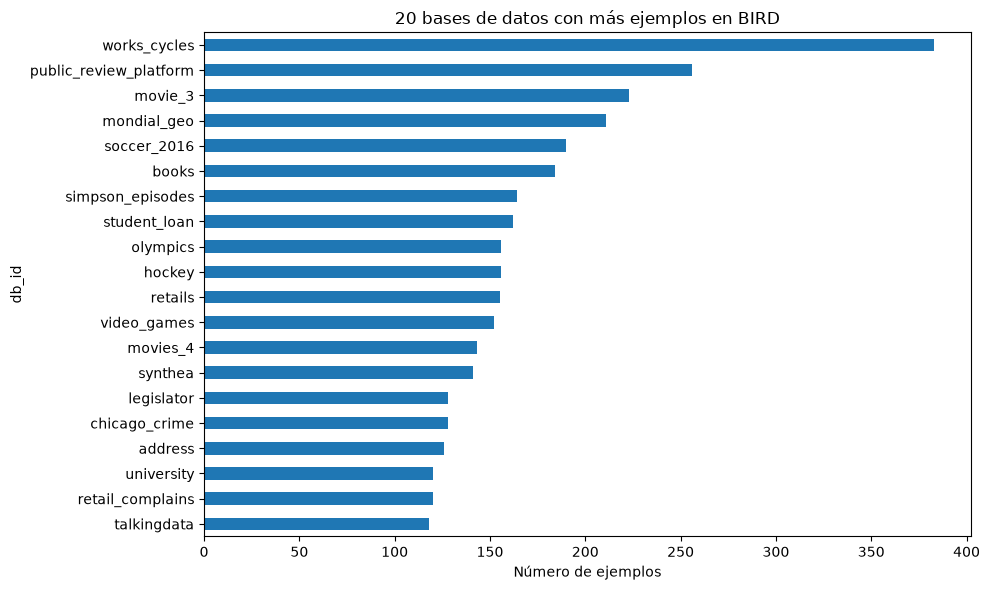

In [11]:
plt.figure(figsize=(10, 6))
top_db.sort_values().plot(kind="barh")
plt.title("20 bases de datos con más ejemplos en BIRD")
plt.xlabel("Número de ejemplos")
plt.ylabel("db_id")
plt.tight_layout()
guardar_grafica("01_top_bases_datos")
plt.show()

## 6. Uso del campo `evidence`

,frecuencia
has_evidence,
Con evidence,6129
Sin evidence,472


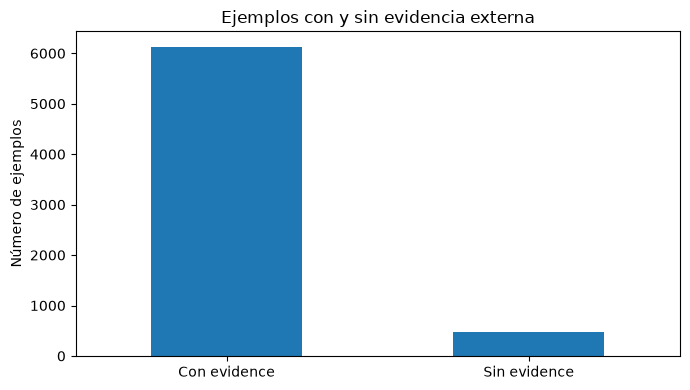

In [12]:
df["has_evidence"] = df["evidence"].fillna("").str.strip().ne("")

evidence_freq = df["has_evidence"].value_counts().rename(
    index={True: "Con evidence", False: "Sin evidence"}
)

display(evidence_freq.to_frame("frecuencia"))

plt.figure(figsize=(7, 4))
evidence_freq.plot(kind="bar")
plt.title("Ejemplos con y sin evidencia externa")
plt.xlabel("")
plt.ylabel("Número de ejemplos")
plt.xticks(rotation=0)
plt.tight_layout()
guardar_grafica("02_evidencia_si_no")
plt.show()

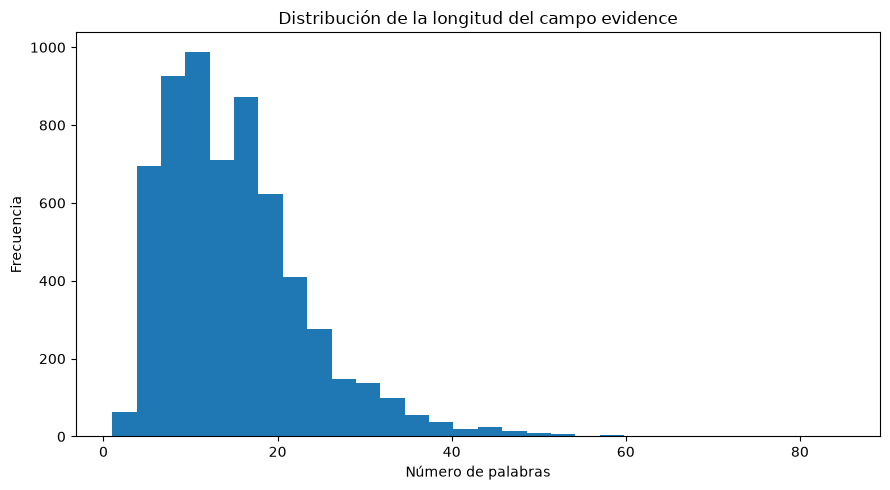

In [13]:
# Longitud de la evidencia para los registros que sí contienen evidence.
evidence_nonempty = df.loc[df["has_evidence"], "evidence_words"]

plt.figure(figsize=(9, 5))
plt.hist(evidence_nonempty, bins=30)
plt.title("Distribución de la longitud del campo evidence")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.tight_layout()
guardar_grafica("03_longitud_evidencia")
plt.show()

## 7. Frecuencia de construcciones SQL

Analizar palabras reservadas y estructuras SQL permite aproximar la complejidad de los ejemplos y determinar qué tipos de razonamiento debe aprender el modelo.

In [14]:
def sql_features(sql):
    s = str(sql).upper()
    return {
        "JOIN": bool(re.search(r"\bJOIN\b", s)),
        "GROUP BY": bool(re.search(r"\bGROUP\s+BY\b", s)),
        "ORDER BY": bool(re.search(r"\bORDER\s+BY\b", s)),
        "HAVING": bool(re.search(r"\bHAVING\b", s)),
        "DISTINCT": bool(re.search(r"\bDISTINCT\b", s)),
        "LIMIT": bool(re.search(r"\bLIMIT\b", s)),
        "UNION": bool(re.search(r"\bUNION\b", s)),
        "INTERSECT": bool(re.search(r"\bINTERSECT\b", s)),
        "EXCEPT": bool(re.search(r"\bEXCEPT\b", s)),
        "AGREGACIÓN": bool(re.search(r"\b(COUNT|SUM|AVG|MIN|MAX)\s*\(", s)),
        "SUBCONSULTA": len(re.findall(r"\bSELECT\b", s)) > 1,
    }

features = df["SQL"].apply(sql_features).apply(pd.Series)
sql_freq = features.sum().sort_values(ascending=False)

display(sql_freq.to_frame("número_de_consultas"))

,número_de_consultas
JOIN,5019
AGREGACIÓN,2996
LIMIT,1188
ORDER BY,1122
DISTINCT,814
GROUP BY,645
SUBCONSULTA,503
HAVING,76
UNION,17
EXCEPT,0


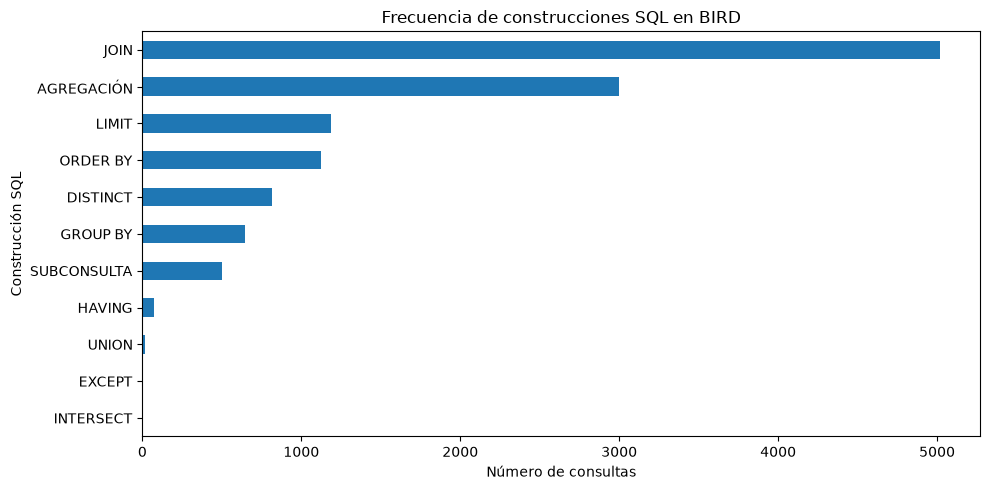

In [15]:
plt.figure(figsize=(10, 5))
sql_freq.sort_values().plot(kind="barh")
plt.title("Frecuencia de construcciones SQL en BIRD")
plt.xlabel("Número de consultas")
plt.ylabel("Construcción SQL")
plt.tight_layout()
guardar_grafica("04_construcciones_sql")
plt.show()

## 8. Histogramas de longitud

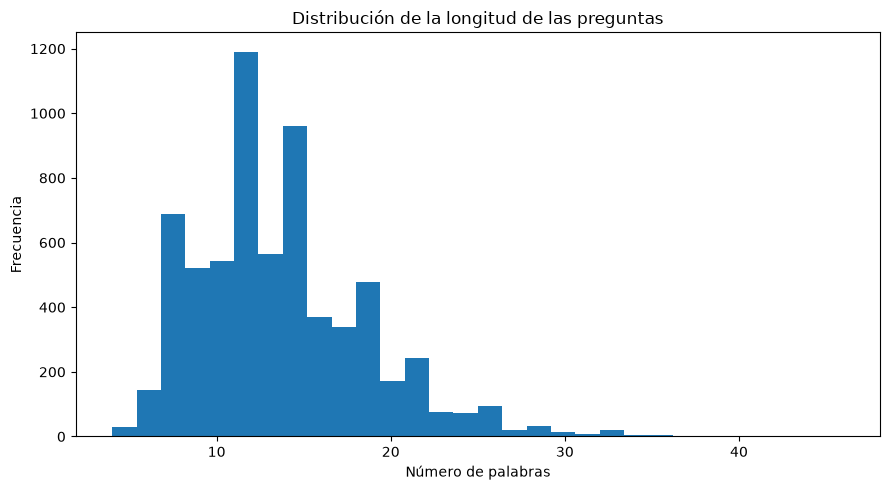

In [16]:
plt.figure(figsize=(9, 5))
plt.hist(df["question_words"], bins=30)
plt.title("Distribución de la longitud de las preguntas")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.tight_layout()
guardar_grafica("05_longitud_preguntas")
plt.show()

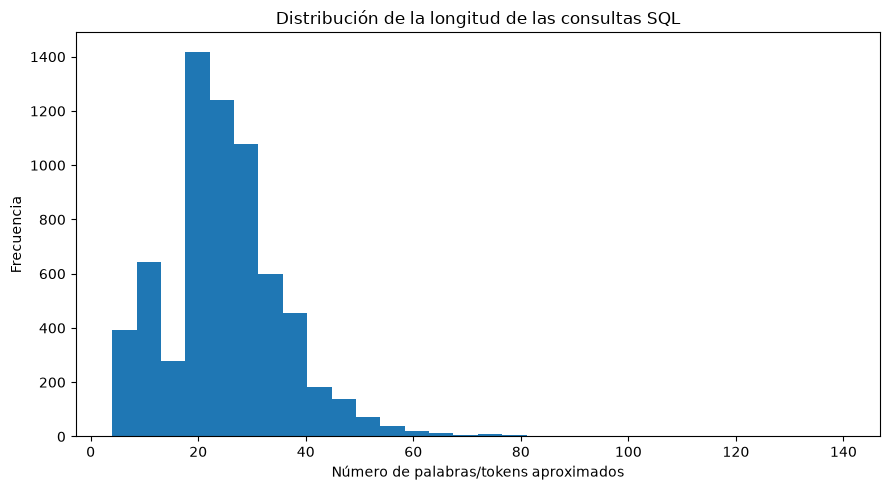

In [17]:
plt.figure(figsize=(9, 5))
plt.hist(df["sql_words"], bins=30)
plt.title("Distribución de la longitud de las consultas SQL")
plt.xlabel("Número de palabras/tokens aproximados")
plt.ylabel("Frecuencia")
plt.tight_layout()
guardar_grafica("06_longitud_sql")
plt.show()

## 9. Diagramas de dispersión

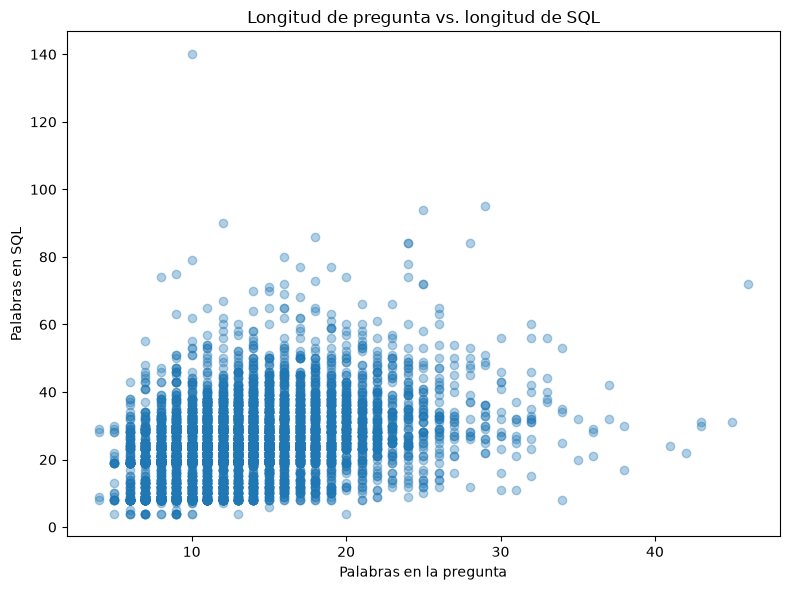

Correlación pregunta-SQL: 0.353


In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(df["question_words"], df["sql_words"], alpha=0.35)
plt.title("Longitud de pregunta vs. longitud de SQL")
plt.xlabel("Palabras en la pregunta")
plt.ylabel("Palabras en SQL")
plt.tight_layout()
guardar_grafica("07_pregunta_vs_sql")
plt.show()

corr_q_sql = df[["question_words", "sql_words"]].corr().iloc[0, 1]
print(f"Correlación pregunta-SQL: {corr_q_sql:.3f}")

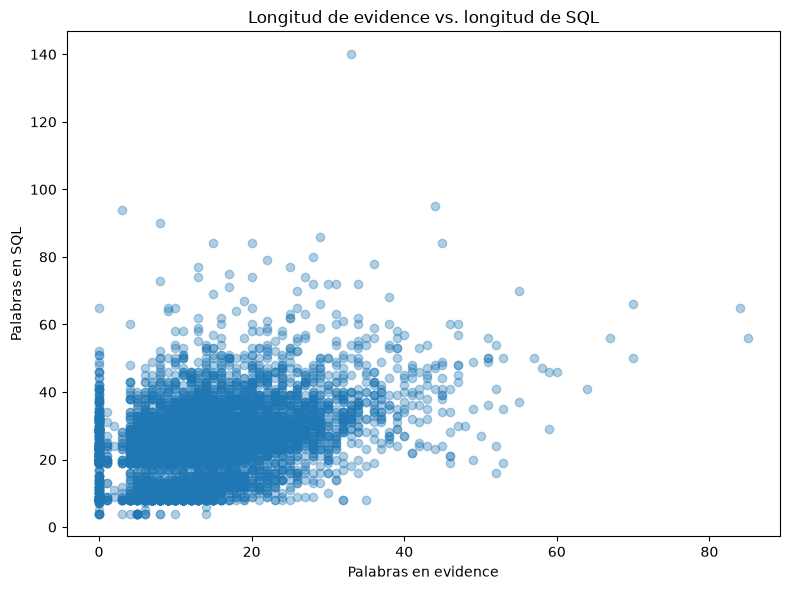

Correlación evidence-SQL: 0.403


In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(df["evidence_words"], df["sql_words"], alpha=0.35)
plt.title("Longitud de evidence vs. longitud de SQL")
plt.xlabel("Palabras en evidence")
plt.ylabel("Palabras en SQL")
plt.tight_layout()
guardar_grafica("08_evidence_vs_sql")
plt.show()

corr_e_sql = df[["evidence_words", "sql_words"]].corr().iloc[0, 1]
print(f"Correlación evidence-SQL: {corr_e_sql:.3f}")

## 10. Nube de palabras de las preguntas

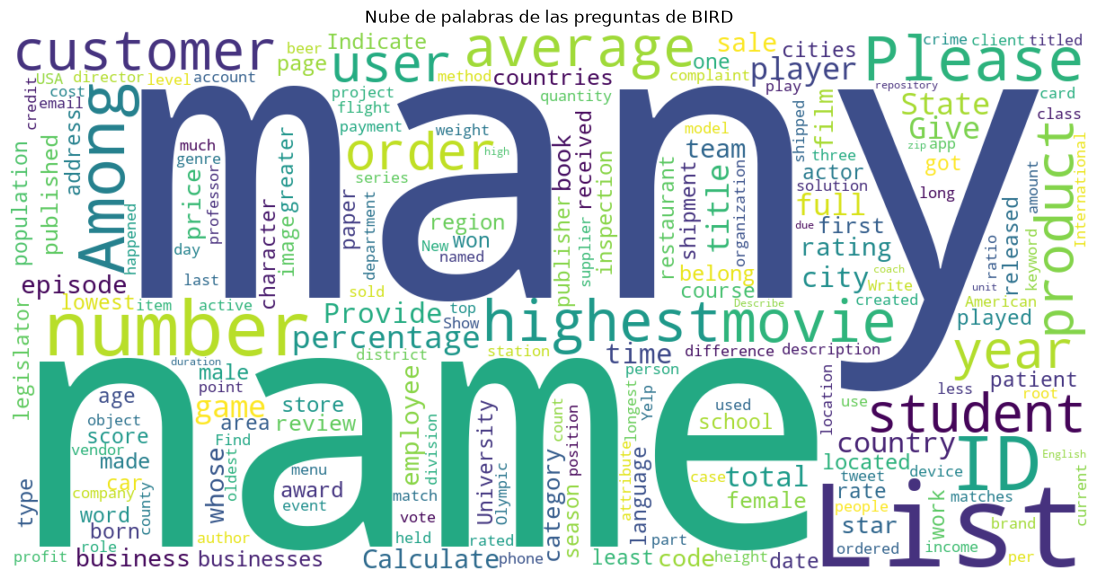

In [20]:
texto_preguntas = " ".join(df["question"].dropna().astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False
).generate(texto_preguntas)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de las preguntas de BIRD")
guardar_grafica("09_nube_palabras")
plt.show()

## 11. Palabras más frecuentes en las preguntas

,palabra,frecuencia
0,list,1160
1,name,919
2,number,666
3,among,519
4,most,477
5,please,459
6,highest,386
7,average,362
8,names,335
9,percentage,312


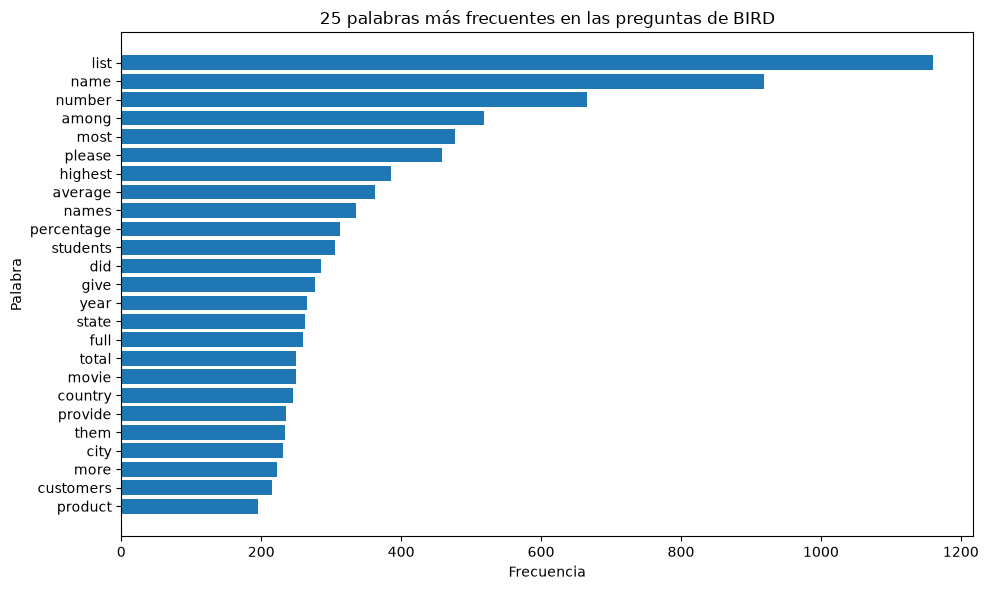

In [21]:
stopwords = {
    "the", "a", "an", "of", "in", "on", "to", "and", "is", "are", "was", "were",
    "what", "which", "who", "how", "many", "for", "with", "from", "that", "have",
    "has", "do", "does", "all", "their", "than", "by", "be", "as", "there"
}

tokens = re.findall(r"[A-Za-z]+", texto_preguntas.lower())
tokens = [t for t in tokens if t not in stopwords and len(t) > 2]

freq = Counter(tokens).most_common(25)
freq_df = pd.DataFrame(freq, columns=["palabra", "frecuencia"])
display(freq_df)

plt.figure(figsize=(10, 6))
plt.barh(freq_df["palabra"][::-1], freq_df["frecuencia"][::-1])
plt.title("25 palabras más frecuentes en las preguntas de BIRD")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.tight_layout()
guardar_grafica("10_frecuencia_palabras")
plt.show()

## 12. Ejemplos cualitativos

In [22]:
# Revisamos ejemplos de distinta longitud de consulta SQL.
muestra = pd.concat([
    df.nsmallest(3, "sql_words"),
    df.sample(min(3, len(df)), random_state=42),
    df.nlargest(3, "sql_words")
])

display(muestra[["db_id", "question", "evidence", "SQL", "sql_words"]])

,db_id,question,evidence,SQL,sql_words
2431,books,Indicate the last number of each street.,"street refers to street_name; last number of each street refers to Substr (street_number, -1)",SELECT street_number FROM address,4
3854,movies_4,What is the longest runtime of all movies?,longest runtime refers to max(runtime),SELECT MAX(runtime) FROM movie,4
4407,simpson_episodes,Find the average height for each person.,"average high = Divide(Sum(height_meters), Count(name))",SELECT AVG(height_meters) FROM Person;,4
4256,professional_basketball,"Among the NBA All-star players in 1996 season , which have more than 70% free throw rate? Please give their player id.",NBA refers to lgID = 'NBA'; in 1996 season refers to season_id = 1996; more than 70% free throw rate refers to ft_ma...,SELECT playerID FROM player_allstar WHERE season_id = 1996 AND CAST(ft_made AS REAL) * 100 / ft_attempted > 70,18
3167,university,Calculate the total number of students in universities located in Sweden.,located in Sweden refers to country_name = 'Sweden'; number of students refers to num_students,SELECT SUM(T2.num_students) FROM university AS T1 INNER JOIN university_year AS T2 ON T1.id = T2.university_id INNER...,28
6303,menu,Tally the dishes that have appeared on the menu for more than 100 years.,"appeared on the menu for more than 100 years = SUBTRACT(last_appeared, first_appeared) > 100;",SELECT T1.name FROM Dish AS T1 INNER JOIN MenuItem AS T2 ON T1.id = T2.dish_id WHERE T1.last_appeared - T1.first_app...,21
3826,retail_complains,Compute the average time in minute for each age group,teenager refers to 13 < age < = 19; adult refers to 19 < age < = 65; elder refers to age < = 65; highest average tim...,"SELECT CAST(SUM(CASE WHEN T1.age > 13 AND T1.age <= 19 THEN 60 * strftime('%H', ser_time) + strftime('%M', ser_time)...",140
6564,bike_share_1,For the rides that started at Market at 10th station and ended at South Van Ness at Market station in August of 2013...,started at refers to start_station_name; start_station_name = 'Market at 10th'; ended at refers to end_station_name;...,SELECT T1.start_date FROM trip AS T1 INNER JOIN weather AS T2 ON T2.zip_code = T1.zip_code AND T2.date = SUBSTR(CAST...,95
4225,european_football_1,How many teams that played in the 2012 season belong to any of the English divisions and what percentage play in eac...,matches = Div,SELECT ( SELECT COUNT(T1.Div) AS total FROM matchs T1 INNER JOIN divisions T2 ON T2.division = T1.Div WHERE T2.count...,94


## 13. Justificación del uso de BIRD

BIRD es adecuado para este proyecto porque reproduce de manera directa la tarea de **Text-to-SQL** y complementa a Spider con escenarios de mayor complejidad y con información externa asociada a las preguntas.

El campo `evidence` resulta particularmente relevante para estudiar modelos con razonamiento explícito o mecanismos adicionales de recuperación de contexto. Una pregunta puede requerir no solo identificar tablas y columnas apropiadas, sino también comprender una definición, una relación o un criterio que no aparece literalmente en el texto de la pregunta.

El conjunto también contiene múltiples bases de datos, lo cual permite estudiar la capacidad del modelo para operar en diferentes dominios. La diversidad de estructuras SQL observada en el análisis —por ejemplo agregaciones, ordenamientos, agrupamientos y subconsultas— lo convierte en un conjunto apropiado para evaluar modelos que deban producir consultas SQL ejecutables y semánticamente correctas.

Finalmente, utilizar la versión filtrada permite trabajar con un conjunto sometido a una revisión adicional de calidad, reduciendo parte del ruido presente en el entrenamiento original.

Por estas razones, BIRD es apropiado para evaluar **generación SQL, razonamiento condicionado por conocimiento externo, schema linking y generalización entre bases de datos**.

## Referencias

- Li, J. et al. (2024). *Can LLM Already Serve as a Database Interface? A Big Bench for Large-Scale Database Grounded Text-to-SQLs*. NeurIPS.
- Proyecto BIRD: https://bird-bench.github.io/
- Dataset utilizado: https://huggingface.co/datasets/birdsql/bird23-train-filtered

## Análisis e interpretación de las gráficas

Las visualizaciones describen la diversidad de bases de datos, el contenido de las preguntas y la complejidad sintáctica de las consultas BIRD-SQL.

- **Distribución por base de datos:** los ejemplos abarcan 69 bases y no se distribuyen uniformemente. `works_cycles` aporta la mayor cantidad (383), seguida de `public_review_platform` (256) y `movie_3` (223).
- **Uso y longitud de `evidence`:** 6.129 de los 6.601 registros (92,85 %) tienen evidencia no vacía; 472 no la tienen. El histograma muestra la variación en la longitud de ese contexto auxiliar.
- **Construcciones SQL:** predominan `JOIN` (5.019 consultas) y las agregaciones (2.996). También aparecen `LIMIT` (1.188), `ORDER BY` (1.122), `DISTINCT` (814), `GROUP BY` (645) y subconsultas (503). `HAVING`, `UNION`, `EXCEPT` e `INTERSECT` son menos frecuentes o no aparecen en esta version. Las categorías pueden coincidir en una misma consulta.
- **Longitud de los textos:** las preguntas tienen una media de 13,61 palabras y las consultas SQL de 25,04; la consulta más larga alcanza 140 palabras segun la tokenizacion por espacios.
- **Relación entre longitudes:** la correlación entre pregunta y SQL es 0,353; entre `evidence` y SQL, 0,403. Ambas asociaciones son positivas y moderadas: los textos más largos tienden a aparecer junto con consultas más largas, aunque la longitud no determina por si sola su estructura.
- **Nube y frecuencia de palabras:** destacan *list*, *name*, *number*, *among*, *most* y *average*. Esto apunta a solicitudes de listado, conteo, comparación y agregacion. La nube es descriptiva y no sustituye un análisis semántico.

En conjunto, las gráficas muestran que BIRD combina preguntas relativamente breves con consultas SQL de longitud y estructura variadas, y que la mayoria de los ejemplos incluye evidencia auxiliar. Esto respalda su utilidad para estudiar Text-to-SQL con contexto adicional.